# Regression — expected cost model, residual = anomaly score

Self-contained: feature engineering, train/test split, and model comparison are all visible here. Evaluation is regression metrics only (MAE/RMSE/R2) — no precision/recall/F1, no dependency on `is_synthetic_anomaly`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('repair_invoice_clean.csv')
df.head()

,repair_id,claim_id,vehicle_id,repair_shop_contact_id,estimate_amount,approved_amount,invoice_amount,paid_amount,repair_start_date,repair_end_date,...,exposure_status,is_repeat_vehicle,is_synthetic_anomaly,anomaly_type,vehicle_claim_count,repair_duration_days,vehicle_age,invoice_vs_estimate_ratio,invoice_vs_approved_ratio,duplicate_flag
0,1,1,5749,217,883.00,859.88,821.28,779.60,2025-11-16,2025-11-18,...,Open,False,False,NaN,1,2,13,0.930102,0.955110,True
1,2,2,1818,152,1659.62,1620.74,1627.69,1621.15,2026-02-23,2026-03-02,...,Closed,False,False,NaN,1,7,6,0.980761,1.004288,False
2,7,6,4529,175,1013.25,844.58,917.77,820.13,2026-04-06,2026-04-12,...,Open,False,False,NaN,1,6,3,0.905769,1.086658,False
3,8,6,4529,175,1231.42,1213.63,1417.89,1211.47,2026-04-06,2026-04-12,...,Open,False,False,NaN,1,6,3,1.151427,1.168305,False
4,9,7,7329,180,2946.86,3039.04,2827.41,2918.91,2025-11-23,2025-11-29,...,Closed,False,False,NaN,1,6,4,0.959465,0.930363,False


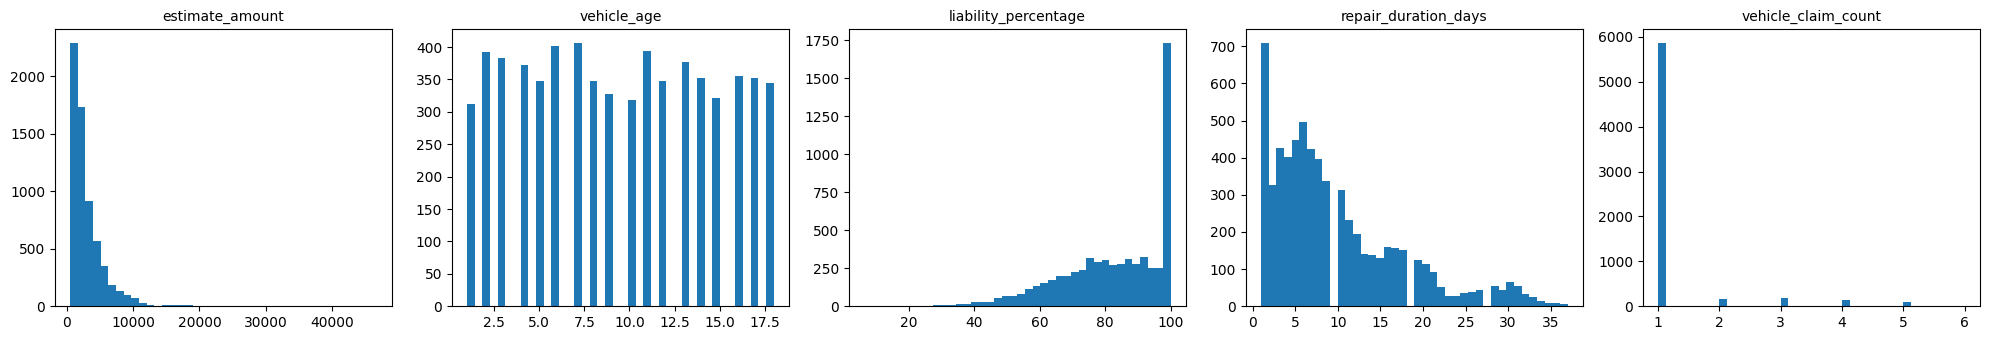

In [3]:
candidate_numeric_cols = ["estimate_amount", "vehicle_age", "liability_percentage", "repair_duration_days", "vehicle_claim_count"]

fig, axes = plt.subplots(1, len(candidate_numeric_cols), figsize=(20, 3.5))
for ax, col in zip(axes, candidate_numeric_cols):
    ax.hist(df[col], bins=40)
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

In [4]:
SEVERITY_ORDER = {"Minor": 0, "Moderate": 1, "Severe": 2, "Total Loss": 3}
df["damage_severity_ordinal"] = df["damage_severity"].map(SEVERITY_ORDER)

df[candidate_numeric_cols].skew().sort_values(ascending=False)

vehicle_claim_count     3.814010
estimate_amount         3.324763
repair_duration_days    1.191277
vehicle_age             0.040454
liability_percentage   -0.783050
dtype: float64

In [5]:
from sklearn.linear_model import Ridge

ab_df = df.copy()
ab_df["log_estimate_amount"] = np.log1p(ab_df["estimate_amount"])
ab_train, ab_test = train_test_split(ab_df, test_size=0.2, random_state=42)

ab_results = []
for feature_col in ["estimate_amount", "log_estimate_amount"]:
    for name, est in [("HistGradientBoosting", HistGradientBoostingRegressor(random_state=42)), ("Ridge", Ridge(alpha=100.0))]:
        m = est.__class__(**est.get_params())
        m.fit(ab_train[[feature_col]], ab_train["invoice_amount"])
        pred = m.predict(ab_test[[feature_col]])
        ab_results.append({"feature": feature_col, "model": name, "R2": r2_score(ab_test["invoice_amount"], pred)})

pd.DataFrame(ab_results)

,feature,model,R2
0,estimate_amount,HistGradientBoosting,0.905991
1,estimate_amount,Ridge,0.918202
2,log_estimate_amount,HistGradientBoosting,0.905991
3,log_estimate_amount,Ridge,0.737518


In [6]:
NUMERIC_FEATURES = ["estimate_amount", "vehicle_age", "liability_percentage", "repair_duration_days", "vehicle_claim_count", "damage_severity_ordinal", "shop_avg_invoice"]
CATEGORICAL_FEATURES = ["make", "model", "claim_severity", "incident_state", "loss_cause"]
TARGET = "invoice_amount"

def build_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
    ])

In [7]:
split_cols = [c for c in NUMERIC_FEATURES if c != "shop_avg_invoice"] + CATEGORICAL_FEATURES + ["repair_shop_contact_id", TARGET]
train_df, test_df = train_test_split(df[split_cols], test_size=0.2, random_state=42)

In [8]:
shop_avg_train = train_df.groupby("repair_shop_contact_id")[TARGET].mean()
global_avg_train = train_df[TARGET].mean()
train_df["shop_avg_invoice"] = train_df["repair_shop_contact_id"].map(shop_avg_train)
test_df["shop_avg_invoice"] = test_df["repair_shop_contact_id"].map(shop_avg_train).fillna(global_avg_train)

In [9]:
X_train, y_train = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES], train_df[TARGET]
X_test, y_test = test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES], test_df[TARGET]

In [10]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

### Ridge (linear baseline)

In [11]:
ridge_model = Pipeline([("pre", build_preprocessor()), ("model", Ridge(alpha=100.0))])
ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['estimate_amount','vehicle_age','liability_percentage',..., 'claim_severity','incident_state','loss_cause']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

In [12]:
ridge_pred = ridge_model.predict(X_test)

In [13]:
print("Ridge  MAE:", mean_absolute_error(y_test, ridge_pred))
print("Ridge RMSE:", mean_squared_error(y_test, ridge_pred) ** 0.5)
print("Ridge   R2:", r2_score(y_test, ridge_pred))

Ridge  MAE: 367.05437876289756
Ridge RMSE: 826.7543806336678
Ridge   R2: 0.9179981154272353


### Random Forest

In [14]:
rf_model = Pipeline([("pre", build_preprocessor()), ("model", RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_depth=None, random_state=42))])
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['estimate_amount','vehicle_age','liability_percentage',..., 'claim_severity','incident_state','loss_cause']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

In [15]:
rf_pred = rf_model.predict(X_test)

In [16]:
print("RandomForest  MAE:", mean_absolute_error(y_test, rf_pred))
print("RandomForest RMSE:", mean_squared_error(y_test, rf_pred) ** 0.5)
print("RandomForest   R2:", r2_score(y_test, rf_pred))

RandomForest  MAE: 321.34094467303447
RandomForest RMSE: 786.2398664192751
RandomForest   R2: 0.925838083215711


### Extra Trees

In [17]:
et_model = Pipeline([("pre", build_preprocessor()), ("model", ExtraTreesRegressor(n_estimators=100, min_samples_leaf=2, max_depth=10, random_state=42))])
et_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['estimate_amount','vehicle_age','liability_percentage',..., 'claim_severity','incident_state','loss_cause']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

In [18]:
et_pred = et_model.predict(X_test)

In [19]:
print("ExtraTrees  MAE:", mean_absolute_error(y_test, et_pred))
print("ExtraTrees RMSE:", mean_squared_error(y_test, et_pred) ** 0.5)
print("ExtraTrees   R2:", r2_score(y_test, et_pred))

ExtraTrees  MAE: 320.41833720902497
ExtraTrees RMSE: 739.0827600023721
ExtraTrees   R2: 0.9344674650330085


### Gradient Boosting

In [20]:
gb_model = Pipeline([("pre", build_preprocessor()), ("model", GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42))])
gb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['estimate_amount','vehicle_age','liability_percentage',..., 'claim_severity','incident_state','loss_cause']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

In [21]:
gb_pred = gb_model.predict(X_test)

In [22]:
print("GradientBoosting  MAE:", mean_absolute_error(y_test, gb_pred))
print("GradientBoosting RMSE:", mean_squared_error(y_test, gb_pred) ** 0.5)
print("GradientBoosting   R2:", r2_score(y_test, gb_pred))

GradientBoosting  MAE: 307.6051371488563
GradientBoosting RMSE: 718.5389246611477
GradientBoosting   R2: 0.9380599682863473


### Hist Gradient Boosting

In [23]:
hgb_model = Pipeline([("pre", build_preprocessor()), ("model", HistGradientBoostingRegressor(random_state=42))])
hgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['estimate_amount','vehicle_age','liability_percentage',..., 'claim_severity','incident_state','loss_cause']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

In [24]:
hgb_pred = hgb_model.predict(X_test)

In [25]:
print("HistGradientBoosting  MAE:", mean_absolute_error(y_test, hgb_pred))
print("HistGradientBoosting RMSE:", mean_squared_error(y_test, hgb_pred) ** 0.5)
print("HistGradientBoosting   R2:", r2_score(y_test, hgb_pred))

HistGradientBoosting  MAE: 331.3159696413545
HistGradientBoosting RMSE: 834.2467886334452
HistGradientBoosting   R2: 0.9165051072682251


### LightGBM

In [26]:
lgbm_model = Pipeline([("pre", build_preprocessor()), ("model", LGBMRegressor(n_estimators=100, max_depth=10, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1))])
lgbm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['estimate_amount','vehicle_age','liability_percentage',..., 'claim_severity','incident_state','loss_cause']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

In [27]:
lgbm_pred = lgbm_model.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [28]:
print("LightGBM  MAE:", mean_absolute_error(y_test, lgbm_pred))
print("LightGBM RMSE:", mean_squared_error(y_test, lgbm_pred) ** 0.5)
print("LightGBM   R2:", r2_score(y_test, lgbm_pred))

LightGBM  MAE: 322.2434259147222
LightGBM RMSE: 805.331367617647
LightGBM   R2: 0.9221927520868064


### XGBoost

In [29]:
xgb_model = Pipeline([("pre", build_preprocessor()), ("model", XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42))])
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['estimate_amount','vehicle_age','liability_percentage',..., 'claim_severity','incident_state','loss_cause']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

In [30]:
xgb_pred = xgb_model.predict(X_test)

In [31]:
print("XGBoost  MAE:", mean_absolute_error(y_test, xgb_pred))
print("XGBoost RMSE:", mean_squared_error(y_test, xgb_pred) ** 0.5)
print("XGBoost   R2:", r2_score(y_test, xgb_pred))

XGBoost  MAE: 315.41647544622367
XGBoost RMSE: 820.601703469827
XGBoost   R2: 0.9192140842394954


### Comparing all seven on the test set

In [32]:
all_preds = {
    "Ridge": ridge_pred,
    "RandomForest": rf_pred,
    "ExtraTrees": et_pred,
    "GradientBoosting": gb_pred,
    "HistGradientBoosting": hgb_pred,
    "LightGBM": lgbm_pred,
    "XGBoost": xgb_pred,
}

comparison_df = pd.DataFrame({
    name: [mean_absolute_error(y_test, pred), mean_squared_error(y_test, pred) ** 0.5, r2_score(y_test, pred)]
    for name, pred in all_preds.items()
}, index=["MAE", "RMSE", "R2"]).T
comparison_df

,MAE,RMSE,R2
Ridge,367.054379,826.754381,0.917998
RandomForest,321.340945,786.239866,0.925838
ExtraTrees,320.418337,739.082760,0.934467
GradientBoosting,307.605137,718.538925,0.938060
HistGradientBoosting,331.315970,834.246789,0.916505
LightGBM,322.243426,805.331368,0.922193
XGBoost,315.416475,820.601703,0.919214


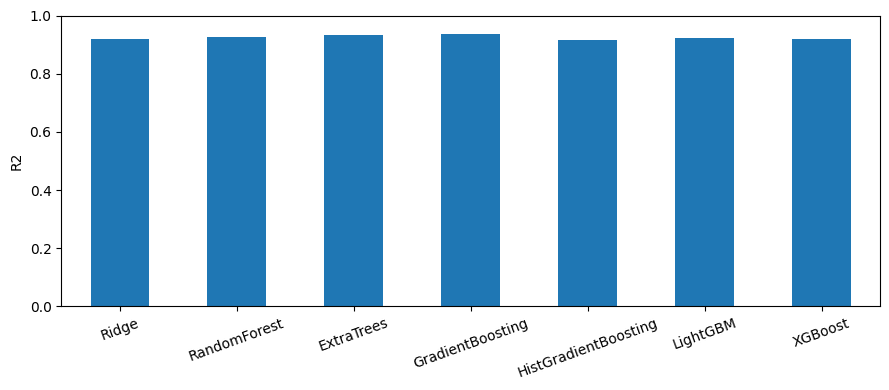

In [33]:
fig, ax = plt.subplots(figsize=(9, 4))
comparison_df["R2"].plot(kind="bar", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("R2")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Top 3 by R2 — closer look

In [34]:
top3_names = comparison_df["R2"].sort_values(ascending=False).head(3).index.tolist()
top3_names

['GradientBoosting', 'ExtraTrees', 'RandomForest']

In [35]:
model_lookup = {
    "Ridge": ridge_model, "RandomForest": rf_model, "ExtraTrees": et_model,
    "GradientBoosting": gb_model, "HistGradientBoosting": hgb_model,
    "LightGBM": lgbm_model, "XGBoost": xgb_model,
}

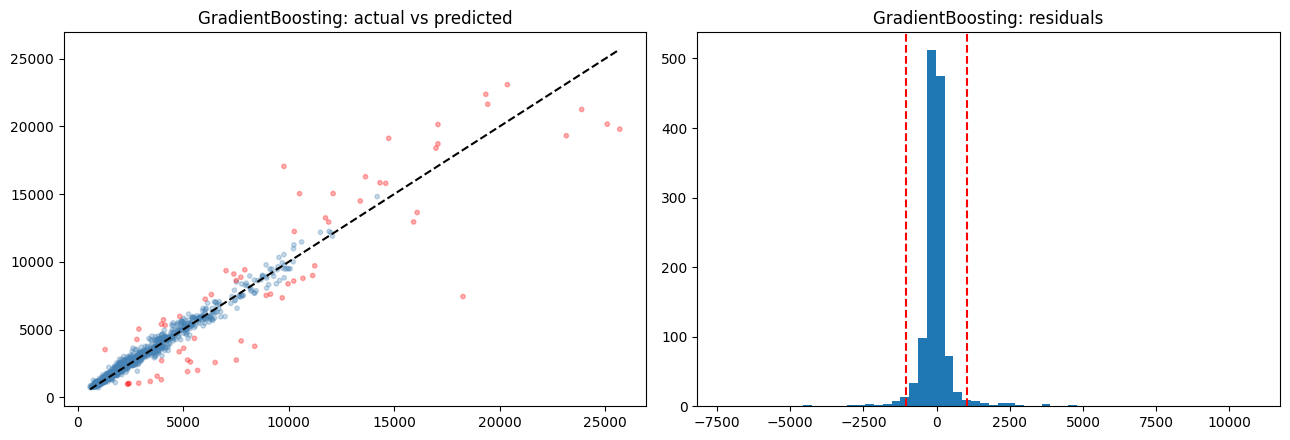

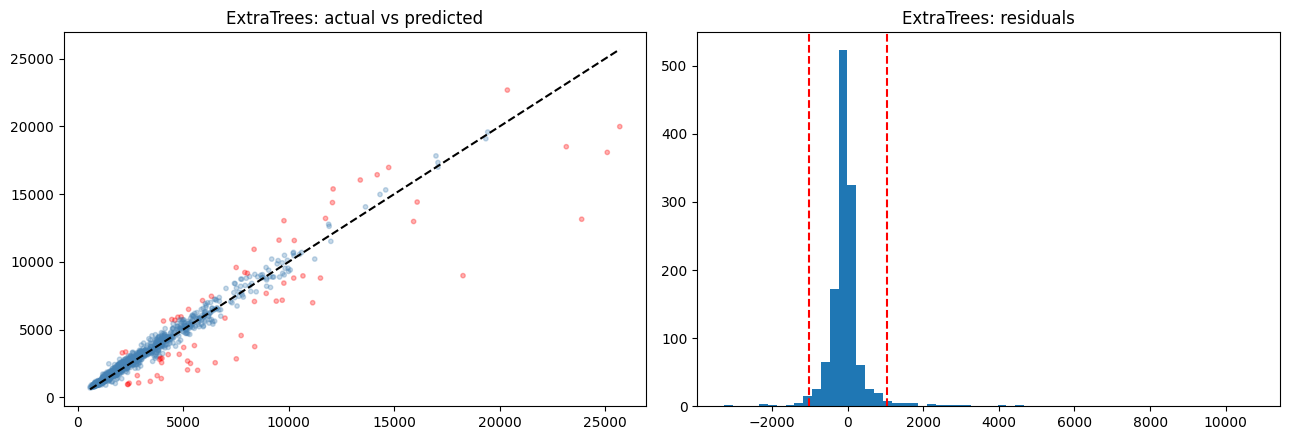

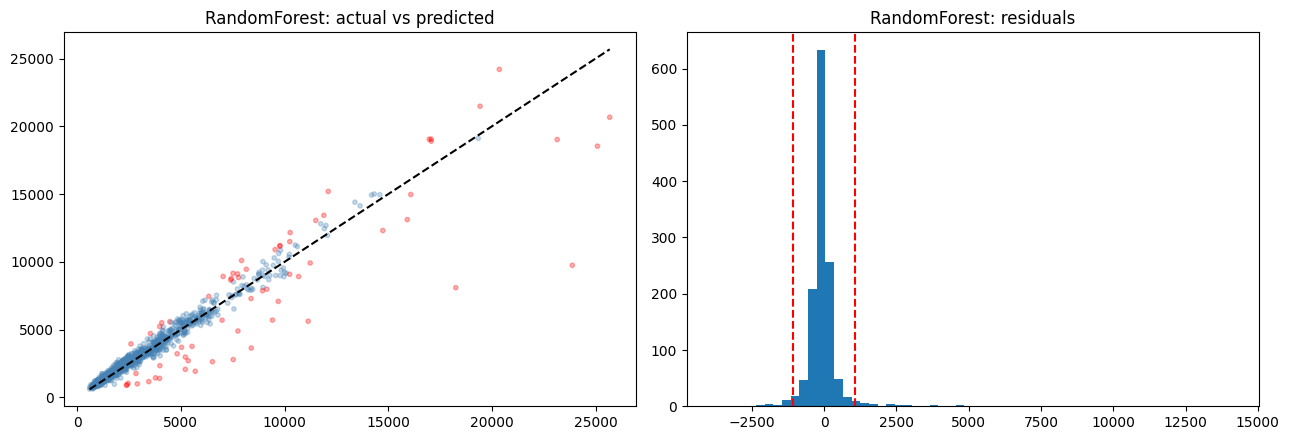

In [36]:
for name in top3_names:
    pred = all_preds[name]
    resid = y_test.values - pred
    thr = np.percentile(np.abs(resid), 95)
    flag = np.abs(resid) > thr

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(y_test, pred, s=10, alpha=0.3, c=pd.Series(flag).map({True: "red", False: "steelblue"}))
    lims = [y_test.min(), y_test.max()]
    axes[0].plot(lims, lims, "k--")
    axes[0].set_title(f"{name}: actual vs predicted")

    axes[1].hist(resid, bins=60)
    axes[1].axvline(thr, color="red", ls="--")
    axes[1].axvline(-thr, color="red", ls="--")
    axes[1].set_title(f"{name}: residuals")
    plt.tight_layout()
    plt.show()

### Selecting one model

Best R2 among the top 3 wins.

In [37]:
best_model_name = comparison_df.loc[top3_names, "R2"].idxmax()
best_model = model_lookup[best_model_name]
best_pred = all_preds[best_model_name]
print("selected:", best_model_name)

selected: GradientBoosting


In [38]:
residual = y_test.values - best_pred
FLAG_PCT = 95
threshold = np.percentile(np.abs(residual), FLAG_PCT)
test_df["reg_flag"] = np.abs(residual) > threshold
test_df["reg_flag"].value_counts()

reg_flag
False    1227
True       65
Name: count, dtype: int64

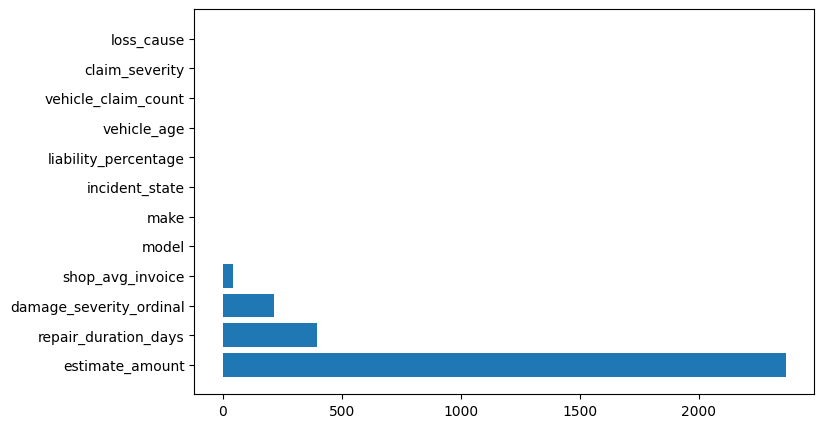

In [39]:
imp = permutation_importance(best_model, X_test, y_test, n_repeats=5, random_state=42, scoring="neg_mean_absolute_error")
order = np.argsort(imp.importances_mean)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(np.array(NUMERIC_FEATURES + CATEGORICAL_FEATURES)[order], imp.importances_mean[order])
plt.show()

duplicate_flag  False  True 
reg_flag                    
False           0.927  0.073
True            0.954  0.046
0.046153846153846156 0.07198142414860681


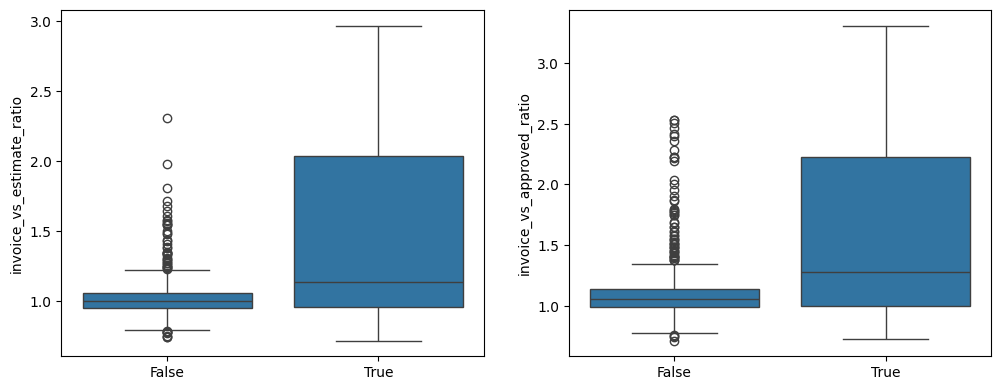

In [40]:
test_extra = df.loc[test_df.index, ["duplicate_flag", "invoice_vs_estimate_ratio", "invoice_vs_approved_ratio"]]

ct = pd.crosstab(test_df["reg_flag"], test_extra["duplicate_flag"], normalize="index")
print(ct.round(3))
print(test_extra.loc[test_df["reg_flag"].values, "duplicate_flag"].mean(), test_extra["duplicate_flag"].mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, ["invoice_vs_estimate_ratio", "invoice_vs_approved_ratio"]):
    sns.boxplot(x=test_df["reg_flag"].values, y=test_extra[col].values, ax=ax)
    ax.set_ylabel(col)
plt.show()

## Scoring a new data point

Uses `best_model` (the winner selected above) and `shop_avg_train`/`global_avg_train` from the split.

In [41]:
def score_new_point(record, actual_invoice):
    row = dict(record)
    row["damage_severity_ordinal"] = SEVERITY_ORDER[row.pop("damage_severity")]
    row["shop_avg_invoice"] = shop_avg_train.get(row["repair_shop_contact_id"], global_avg_train)

    row_df = pd.DataFrame([row])[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    pred = best_model.predict(row_df)[0]
    resid = actual_invoice - pred
    return {"predicted": pred, "actual": actual_invoice, "residual": resid, "threshold": threshold, "reg_flag": abs(resid) > threshold}

In [42]:
typical_point = {"estimate_amount": 2265.50, "vehicle_age": 9, "liability_percentage": 85.0, "repair_duration_days": 6, "vehicle_claim_count": 1,
    "make": "Toyota", "model": "Camry", "damage_severity": "Moderate", "claim_severity": "Medium", "incident_state": "CA", "loss_cause": "Rear-end Collision", "repair_shop_contact_id": 217}

suspicious_point = {"estimate_amount": 2400.00, "vehicle_age": 2, "liability_percentage": 22.0, "repair_duration_days": 6, "vehicle_claim_count": 1,
    "make": "Tesla", "model": "Model 3", "damage_severity": "Minor", "claim_severity": "Low", "incident_state": "CA", "loss_cause": "Parking Lot Incident", "repair_shop_contact_id": 132}

print("typical", score_new_point(typical_point, 2320.00))
print("suspicious", score_new_point(suspicious_point, 18250.00))

typical {'predicted': 2327.7679742637456, 'actual': 2320.0, 'residual': -7.7679742637456, 'threshold': 1036.114931827575, 'reg_flag': False}
suspicious {'predicted': 2406.502712602995, 'actual': 18250.0, 'residual': 15843.497287397005, 'threshold': 1036.114931827575, 'reg_flag': True}
